# WEEK 8: SHAP Analysis 

**Bias Analysis in ML Models using Explainable AI**  
**Models:** DT (Balanced) and Logistic Regression (Balanced)  
**This Notebook:** SHapley Additive exPlanations (SHAP)

*Goal: To understand WHY the models make the decisions they do.*
> Week 7 told us that female FNR is 3-4x higher than male FNR. This week we find out which features are driving this and if  the model reasons differently for different demographic groups

## SECTION 0: Imports and Setup 


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib

plt.style.use('seaborn-v0_8-whitegrid')
print('All libraries loaded successfully.')

# Load preprocessed data
X_train = pd.read_csv('X_train.csv')
X_test = pd.read_csv('X_test.csv')
y_train = pd.read_csv('y_train.csv').squeeze()
y_test = pd.read_csv('y_test.csv').squeeze()

# Load balanced models trained in Week 7
lr_bal = joblib.load('lr_balanced_model.pkl')
dt_bal = joblib.load('dt_balanced_model.pkl')

# Load sensitive columns and eval dataframe
sensitive = pd.read_csv('sensitive_test.csv')
df_eval = pd.read_csv('df_eval.csv')

print('Data and models loaded successfully.')
print(f'X_test shape: {X_test.shape}')
print(f'Feature names: {list(X_test.columns)}')

All libraries loaded successfully.
Data and models loaded successfully.
X_test shape: (6033, 12)
Feature names: ['age', 'workclass', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


## SECTION 1: What is SHAP? 
SHAP (SHapley Additive exPlanations) assigns each feature a value that represents its contribution to a specific prediction.

**Key concepts:**
- SHAP value > 0: this feature pushed the prediction TOWARD >50K
- SHAP value < 0: this feature pushed the prediction TOWARD <=50K
- SHAP value = 0: this feature had no effect on this prediction

The base value (expected value) is what the model would predict if we knew nothing about the individual — essentially the average prediction across the entire dataset.

For any individual prediction:
 base_value + sum(all SHAP values) = final model output

**Two types of explainers used in this project:**
- TreeExplainer: exact SHAP values for tree-based models (DT). Fast and exact because it exploits the tree structure directly.
- LinearExplainer: exact SHAP values for linear models (LR). Uses feature correlations to compute contributions.

In [14]:
print(type(shap_values_dt))
print(np.array(shap_values_dt).shape)

<class 'numpy.ndarray'>
(6033, 12, 2)


## SECTION 2: SHAP Explainers 
We use different explainers for each model type.
- TreeExplainer is used for DT — it is exact and fast for tree models.
- LinearExplainer is used for LR — it handles the linear coefficient structure.
  
*Using the wrong explainer would give incorrect SHAP values.*


In [28]:
# DT explainer — TreeExplainer is the correct choice for Decision Trees
explainer_dt = shap.TreeExplainer(dt_bal)
shap_values_dt = explainer_dt.shap_values(X_test)

# shap_values_dt is a list of two arrays:
# shap_values_dt[0] = SHAP values for class 0 (<=50K)
# shap_values_dt[1] = SHAP values for class 1 (>50K)
# We use index [1] throughout — we care about what drives >50K predictions.

print('DT SHAP values computed.')
print(f'Shape: {shap_values_dt[:, :, 1].shape}')  # should be (6033, n_features)

# LR explainer
explainer_lr = shap.LinearExplainer(lr_bal, X_train)
shap_values_lr = explainer_lr.shap_values(X_test)

# For LinearExplainer, shap_values is a single array (not a list)
# because LR is a binary classifier with symmetric SHAP values.
print('LR SHAP values computed.')
print(f'Shape: {shap_values_lr.shape}')

DT SHAP values computed.
Shape: (6033, 12)
LR SHAP values computed.
Shape: (6033, 12)


>**Note:** This version of SHAP returns a 3D array of shape (samples, features, classes)
for tree models. We index [:, :, 1] to extract SHAP values for the positive class
(>50K). Older SHAP versions returned a list where index [1] gave the same result.

## SECTION 3: Global Feature Importance — SHAP Summary Plots 
The summary plots shows two things simultaneously:
 1. Which features matter most overall (y-axis ordering by mean |SHAP|)
 2. How each feature affects predictions (color = feature value, x = SHAP value)

 Reading the plot:
 - A feature far to the right = strongly pushes toward >50K prediction
 - A feature far to the left = strongly pushes toward <=50K prediction
 - Red dots = high feature value, Blue dots = low feature value
 - Example: if 'relationship' has red dots on the right, high relationship values push toward >50K. If blue dots are on the left, low values push toward <=50K.

This is more informative than standard feature importance, which only tells you magnitude — not direction or distribution.

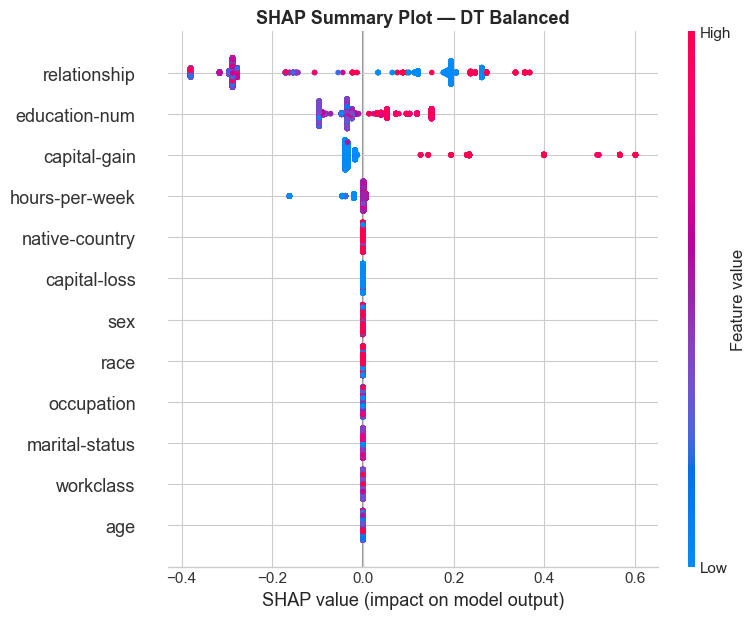

In [30]:
# DT Summary Plot
plt.figure()
shap.summary_plot(
    shap_values_dt[:, :, 1],
    X_test,
    feature_names=X_test.columns.tolist(),
    show=False
)
plt.title('SHAP Summary Plot — DT Balanced', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_dt.png', dpi=150, bbox_inches='tight')
plt.show()

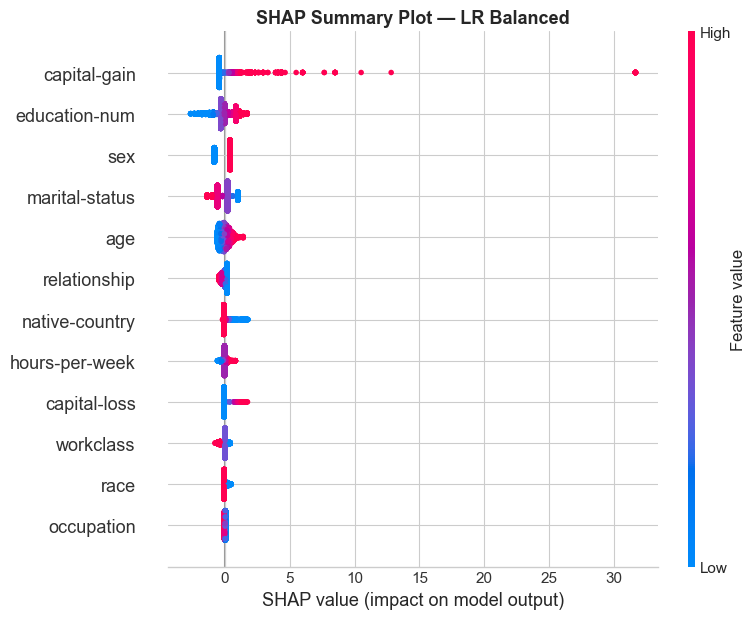

In [31]:
# LR Summary Plot
plt.figure()
shap.summary_plot(
    shap_values_lr,
    X_test,
    feature_names=X_test.columns.tolist(),
    show=False
)
plt.title('SHAP Summary Plot — LR Balanced', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary_lr.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 4: Global Feature Importance — Bar Plot 
The bar plot shows mean absolute SHAP value per feature. This collapses direction — it only shows magnitude of impact.
 Useful for comparing which features matter most across models.

On comparing this with the DT feature importance from Week 6 — we see that the SHAP importance and Gini importance disagree, and SHAP is the more reliable measure because it accounts for feature interactions.


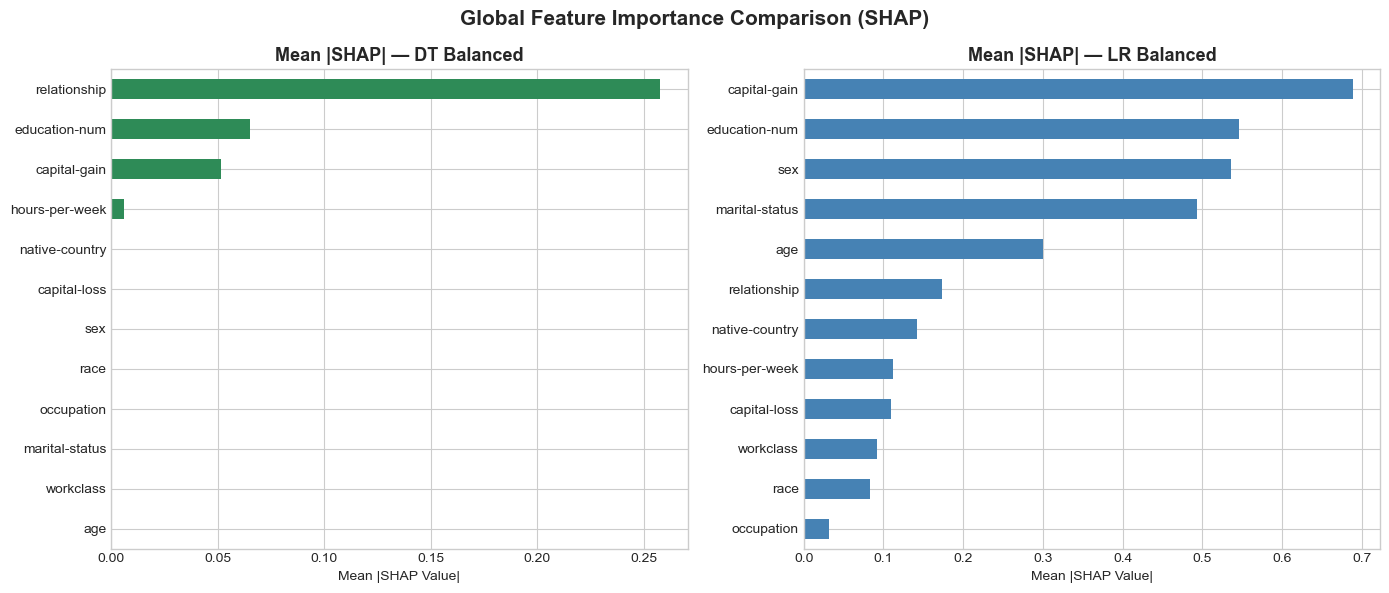

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# DT bar plot
mean_shap_dt = np.abs(shap_values_dt[:, :, 1]).mean(axis=0)
feat_imp_dt = pd.Series(mean_shap_dt, index=X_test.columns).sort_values(ascending=True)
feat_imp_dt.plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Mean |SHAP| — DT Balanced', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Mean |SHAP Value|')

# LR bar plot
mean_shap_lr = np.abs(shap_values_lr).mean(axis=0)
feat_imp_lr = pd.Series(mean_shap_lr, index=X_test.columns).sort_values(ascending=True)
feat_imp_lr.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Mean |SHAP| — LR Balanced', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Mean |SHAP Value|')

plt.suptitle('Global Feature Importance Comparison (SHAP)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## SECTION 5: Top-5 Feature Comparison Table 
Comparing top features across both models side by side. If the ranking is very different, the two models are reasoning differently about the same data — which is important for our audit tool framing.


In [33]:
top5_dt = feat_imp_dt.sort_values(ascending=False).head(5)
top5_lr = feat_imp_lr.sort_values(ascending=False).head(5)

comparison = pd.DataFrame({
    'DT Balanced — Top Features': top5_dt.index.tolist(),
    'DT Mean |SHAP|': top5_dt.values.round(4),
    'LR Balanced — Top Features': top5_lr.index.tolist(),
    'LR Mean |SHAP|': top5_lr.values.round(4),
})

print('Top-5 Feature Comparison (SHAP):')
print(comparison.to_string(index=False))
comparison.to_csv('shap_top5_comparison.csv', index=False)

Top-5 Feature Comparison (SHAP):
DT Balanced — Top Features  DT Mean |SHAP| LR Balanced — Top Features  LR Mean |SHAP|
              relationship          0.2576               capital-gain          0.6885
             education-num          0.0652              education-num          0.5460
              capital-gain          0.0516                        sex          0.5360
            hours-per-week          0.0061             marital-status          0.4931
                       age          0.0000                        age          0.3000


## SECTION 6: Individual Prediction Explanations — Waterfall Plots 
While the summary plot shows global patterns, waterfall plots explain ONE individual prediction in detail.

**Reading a waterfall plot:**
 - Starts at the base value (E[f(x)] — average model output)
 - Each bar shows how much that feature pushed the prediction up or down
 - Ends at the final model output for that individual
 - Red bars = pushed toward >50K, Blue bars = pushed toward <=50K

 We pick 3 individuals:
 1. A correctly classified Male (TP or TN)
 2. A correctly classified Female (TP or TN)
 3. A Female False Negative — predicted <=50K but actually earns >50K. **This is the most important case given our Week 7 findings.**

In [22]:
# Add predictions and sensitive info to work with
df_work = X_test.copy().reset_index(drop=True)
df_work['true'] = y_test.values
df_work['pred_dt'] = dt_bal.predict(X_test)
df_work['sex'] = sensitive['sex'].values

# Case 1: Correctly classified Male (true=1, pred=1)
male_tp_idx = df_work[
    (df_work['sex'] == 'Male') &
    (df_work['true'] == 1) &
    (df_work['pred_dt'] == 1)
].index[0]

# Case 2: Correctly classified Female (true=1, pred=1)
female_tp_idx = df_work[
    (df_work['sex'] == 'Female') &
    (df_work['true'] == 1) &
    (df_work['pred_dt'] == 1)
].index[0]

# Case 3: Female False Negative (true=1, pred=0)
# This is the most important case — a high-income woman the model missed.
female_fn_idx = df_work[
    (df_work['sex'] == 'Female') &
    (df_work['true'] == 1) &
    (df_work['pred_dt'] == 0)
].index[0]

print(f'Male TP index: {male_tp_idx}')
print(f'Female TP index: {female_tp_idx}')
print(f'Female FN index: {female_fn_idx}')

Male TP index: 2
Female TP index: 5
Female FN index: 91


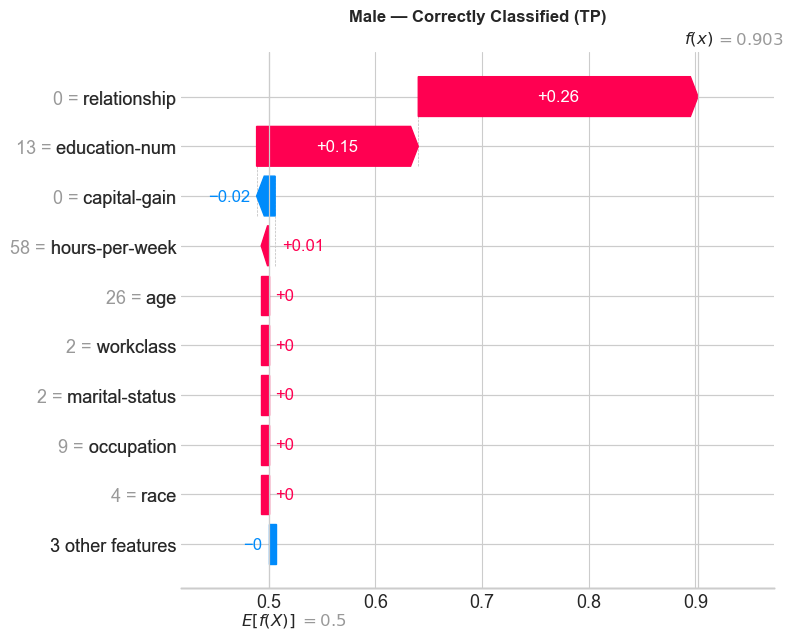

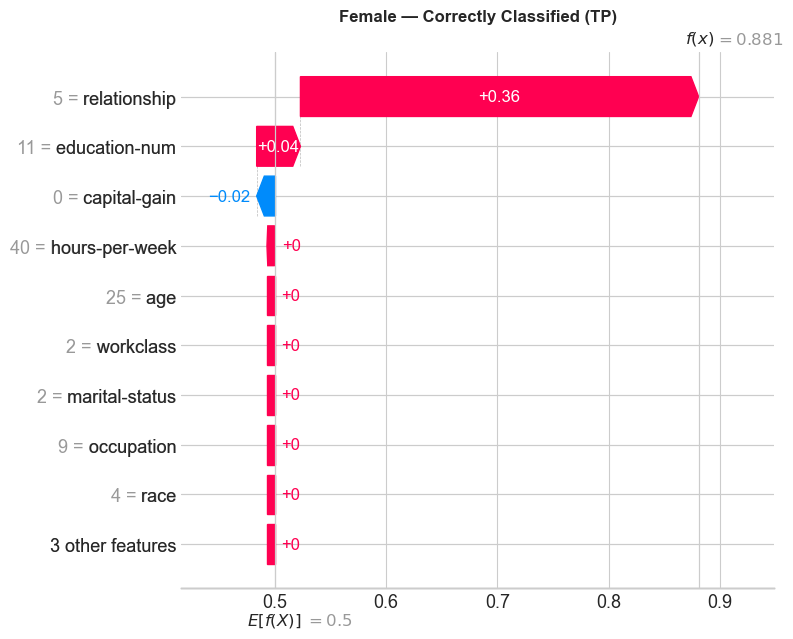

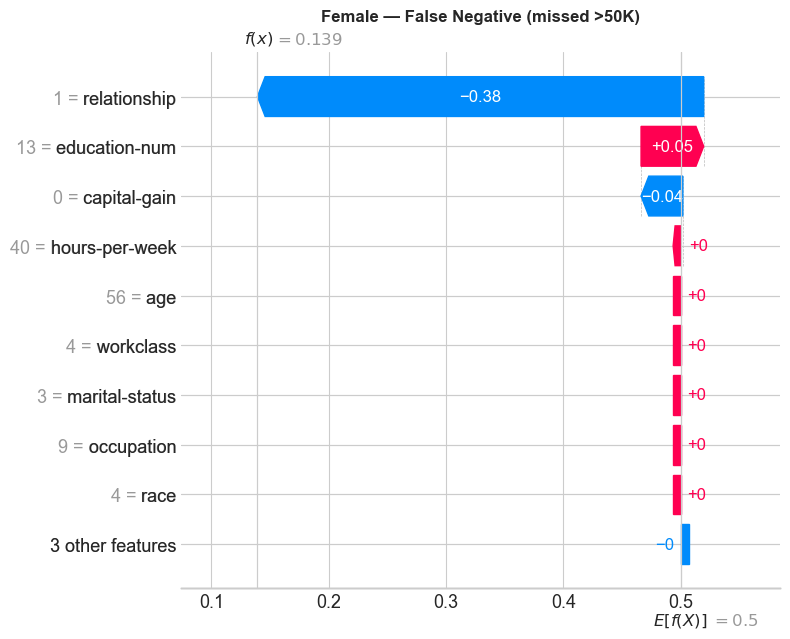

In [24]:
# Waterfall plots — DT Balanced
# These require shap.Explanation objects

explainer_dt_exp = shap.TreeExplainer(dt_bal)
shap_exp_dt = explainer_dt_exp(X_test)

cases = [
    (male_tp_idx, 'Male — Correctly Classified (TP)'),
    (female_tp_idx, 'Female — Correctly Classified (TP)'),
    (female_fn_idx, 'Female — False Negative (missed >50K)'),
]

for idx, title in cases:
    plt.figure()
    shap.plots.waterfall(shap_exp_dt[idx, :, 1], show=False)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.tight_layout()
    fname = (title
    .replace(' ', '_')
    .replace('(', '')
    .replace(')', '')
    .replace('—', '')
    .replace('>', 'gt')
    .replace('<', 'lt')
    .replace('/', '_')
    .strip())
    plt.savefig(f'waterfall_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

## SECTION 7: Save Outputs 

In [34]:
import joblib
import numpy as np

# Save SHAP values for Week 9 (group-wise SHAP analysis)
np.save('shap_values_dt.npy', shap_values_dt[:, :, 1])
np.save('shap_values_lr.npy', shap_values_lr)

# Save explainer base values
np.save('shap_base_dt.npy', np.array([explainer_dt.expected_value[1]]))
np.save('shap_base_lr.npy', np.array([explainer_lr.expected_value]))

print('Saved:')
print('  shap_values_dt.npy     — DT SHAP values for >50K class')
print('  shap_values_lr.npy     — LR SHAP values')
print('  shap_base_dt.npy       — DT base value')
print('  shap_base_lr.npy       — LR base value')
print('  shap_summary_dt.png')
print('  shap_summary_lr.png')
print('  shap_importance_comparison.png')
print('  shap_top5_comparison.csv')
print('  waterfall_*.png        — 3 individual explanations')

Saved:
  shap_values_dt.npy     — DT SHAP values for >50K class
  shap_values_lr.npy     — LR SHAP values
  shap_base_dt.npy       — DT base value
  shap_base_lr.npy       — LR base value
  shap_summary_dt.png
  shap_summary_lr.png
  shap_importance_comparison.png
  shap_top5_comparison.csv
  waterfall_*.png        — 3 individual explanations


## SECTION 8: SHAP and Lime (Cross Check Analysis)

In [29]:
# Get top SHAP features for individuals A, B, C
# Use the same indices your partner used
idx_A = 2
idx_B = 5
idx_C = 91

for label, idx in [('A', idx_A), ('B', idx_B), ('C', idx_C)]:
    shap_row = shap_values_dt[idx, :, 1]
    top_idx = np.argsort(np.abs(shap_row))[::-1][:5]
    print(f'\nIndividual {label} — top SHAP features:')
    for i in top_idx:
        direction = '→ supports >50K' if shap_row[i] > 0 else '→ supports <=50K'
        print(f'  {X_test.columns[i]:<20} {shap_row[i]:>8.4f}  {direction}')


Individual A — top SHAP features:
  relationship           0.2624  → supports >50K
  education-num          0.1516  → supports >50K
  capital-gain          -0.0174  → supports <=50K
  hours-per-week         0.0059  → supports >50K
  native-country         0.0000  → supports <=50K

Individual B — top SHAP features:
  relationship           0.3576  → supports >50K
  education-num          0.0393  → supports >50K
  capital-gain          -0.0169  → supports <=50K
  hours-per-week         0.0007  → supports >50K
  native-country         0.0000  → supports <=50K

Individual C — top SHAP features:
  relationship          -0.3802  → supports <=50K
  education-num          0.0534  → supports >50K
  capital-gain          -0.0356  → supports <=50K
  hours-per-week         0.0017  → supports >50K
  native-country         0.0000  → supports <=50K


**SHAP and LIME agree on the core finding:** relationship is the dominant feature driving predictions for all three individuals, and its value for Individual C is the primary reason she was misclassified.

SHAP confirms this with exact values (+0.2624 for A, +0.3576 for B, −0.3802 for C). LIME's instability on native-country and marital-status is explained by SHAP showing those features contribute exactly 0 — LIME was fitting noise.

**The proxy feature hypothesis is supported:** relationship encodes gender-correlated information, and its outsized negative weight for Individual C explains the high Female FNR found in Week 7. This sets up Week 9's central question: does this pattern hold across all female false negatives, or is Individual C an outlier?